# Lib

In [2]:
from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [3]:
from src.utils.config import *

from src.utils.preprocess_detection import (
    read_yolo_label_file,
    box_iou
)

VAL_IMAGES = VAL_DETECTION / "images"
VAL_LABELS = VAL_DETECTION / "labels"

TEST_IMAGES = TEST_DETECTION / "images"
TEST_LABELS = TEST_DETECTION / "labels"

# Function

## Load Haar Cascade pretrained

In [4]:
def load_haar_detector():
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

    detector = cv2.CascadeClassifier(cascade_path)

    if detector.empty():
        raise RuntimeError("Cannot load Haar Cascade model.")

    return detector

haar_detector = load_haar_detector()
print("Haar Cascade loaded successfully.")

Haar Cascade loaded successfully.


## Detect Faces

In [5]:
def detect_faces_haar(
    gray_image,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30)
):
    """
    Detect faces using Haar Cascade.

    Input:
        gray_image: preprocessed grayscale image

    Output:
        boxes_xyxy: list of boxes [x1, y1, x2, y2]
        elapsed_time: processing time
    """

    start_time = time.time()

    faces_xywh = haar_detector.detectMultiScale(
        gray_image,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    elapsed_time = time.time() - start_time

    boxes_xyxy = []

    for (x, y, w, h) in faces_xywh:
        boxes_xyxy.append([
            int(x),
            int(y),
            int(x + w),
            int(y + h)
        ])

    return boxes_xyxy, elapsed_time

## Draw Bbox

In [6]:
def draw_boxes(
    image,
    boxes,
    color=(0, 255, 0),
    thickness=2,
    label=None,
    show=False,
    title="Detection Result",
    figsize=(8, 6)
):

    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output = image.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            thickness
        )

        if label is not None:
            cv2.putText(
                output,
                label,
                (x1, max(0, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    if show:
        plt.figure(figsize=figsize)
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return output

## Eval

In [7]:
def evaluate_single_image(pred_boxes, gt_boxes, iou_threshold=0.5):
    """
    Evaluate detection result for one image.

    Logic:
        A prediction is TP if IoU >= threshold with an unmatched GT box.
    """

    matched_gt = set()

    true_positive = 0
    false_positive = 0

    iou_values = []

    for pred_box in pred_boxes:
        best_iou = 0.0
        best_gt_idx = -1

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue

            iou = box_iou(pred_box, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            true_positive += 1
            matched_gt.add(best_gt_idx)
            iou_values.append(best_iou)
        else:
            false_positive += 1

    false_negative = len(gt_boxes) - len(matched_gt)

    return {
        "tp": true_positive,
        "fp": false_positive,
        "fn": false_negative,
        "matched_ious": iou_values
    }

In [8]:
def evaluate(
    images_dir,
    labels_dir,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30),
    iou_threshold=0.5,
    max_images=None
):
    image_paths = sorted(list(Path(images_dir).glob("*")))

    if max_images is not None:
        image_paths = image_paths[:max_images]

    records = []

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_time = 0.0
    all_ious = []

    for image_path in tqdm(image_paths, desc="Evaluating Haar Cascade"):
        gray_image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if gray_image is None:
            continue

        height, width = gray_image.shape[:2]

        label_path = Path(labels_dir) / f"{image_path.stem}.txt"

        gt_boxes = read_yolo_label_file(
            label_path=label_path,
            image_width=width,
            image_height=height
        )

        pred_boxes, elapsed_time = detect_faces_haar(
            gray_image=gray_image,
            scale_factor=scale_factor,
            min_neighbors=min_neighbors,
            min_size=min_size
        )

        result = evaluate_single_image(
            pred_boxes=pred_boxes,
            gt_boxes=gt_boxes,
            iou_threshold=iou_threshold
        )

        total_tp += result["tp"]
        total_fp += result["fp"]
        total_fn += result["fn"]
        total_time += elapsed_time
        all_ious.extend(result["matched_ious"])

        records.append({
            "image_name": image_path.name,
            "num_gt": len(gt_boxes),
            "num_pred": len(pred_boxes),
            "tp": result["tp"],
            "fp": result["fp"],
            "fn": result["fn"],
            "time": elapsed_time
        })

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    avg_iou = np.mean(all_ious) if len(all_ious) > 0 else 0.0
    avg_time = total_time / len(image_paths) if len(image_paths) > 0 else 0.0
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    summary = {
        "scale_factor": scale_factor,
        "min_neighbors": min_neighbors,
        "min_size": min_size,
        "iou_threshold": iou_threshold,
        "total_images": len(image_paths),
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "avg_iou": avg_iou,
        "avg_time": avg_time,
        "fps": fps
    }

    records_df = pd.DataFrame(records)

    return summary, records_df

# Main

## Tune Haar Cascade

In [9]:
haar_param_grid = [
    {
        "scale_factor": 1.05,
        "min_neighbors": 3,
        "min_size": (20, 20)
    },
    {
        "scale_factor": 1.05,
        "min_neighbors": 5,
        "min_size": (30, 30)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 3,
        "min_size": (20, 20)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 5,
        "min_size": (30, 30)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 7,
        "min_size": (40, 40)
    },
    {
        "scale_factor": 1.20,
        "min_neighbors": 5,
        "min_size": (40, 40)
    }
]

In [12]:
tuning_results = []

for params in haar_param_grid:
    print("Testing params:", params)

    summary, _ = evaluate(
        images_dir=VAL_IMAGES,
        labels_dir=VAL_LABELS,
        scale_factor=params["scale_factor"],
        min_neighbors=params["min_neighbors"],
        min_size=params["min_size"],
        iou_threshold=0.5,
        max_images=None
    )

    tuning_results.append(summary)

tuning_df = pd.DataFrame(tuning_results)

tuning_df = tuning_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

tuning_df

Testing params: {'scale_factor': 1.05, 'min_neighbors': 3, 'min_size': (20, 20)}


Evaluating Haar Cascade: 100%|██████████| 3286/3286 [05:51<00:00,  9.35it/s]


Testing params: {'scale_factor': 1.05, 'min_neighbors': 5, 'min_size': (30, 30)}


Evaluating Haar Cascade: 100%|██████████| 3286/3286 [04:39<00:00, 11.75it/s]


Testing params: {'scale_factor': 1.1, 'min_neighbors': 3, 'min_size': (20, 20)}


...

Testing params: {'scale_factor': 1.1, 'min_neighbors': 7, 'min_size': (40, 40)}


Evaluating Haar Cascade: 100%|██████████| 3286/3286 [02:06<00:00, 25.95it/s]


Testing params: {'scale_factor': 1.2, 'min_neighbors': 5, 'min_size': (40, 40)}


Evaluating Haar Cascade: 100%|██████████| 3286/3286 [01:23<00:00, 39.17it/s]


,scale_factor,min_neighbors,min_size,iou_threshold,total_images,tp,fp,fn,precision,recall,f1,avg_iou,avg_time,fps
0,1.10,3,"(20, 20)",0.5,3286,5955,7979,18937,0.427372,0.239233,0.306753,0.691487,0.051995,19.232724
1,1.10,5,"(30, 30)",0.5,3286,4814,3470,20078,0.581120,0.193395,0.290210,0.691838,0.039359,25.407109
2,1.05,5,"(30, 30)",0.5,3286,5514,8885,19378,0.382943,0.221517,0.280675,0.687970,0.077980,12.823846
3,1.05,3,"(20, 20)",0.5,3286,6609,18188,18283,0.266524,0.265507,0.266015,0.687463,0.098565,10.145593
4,1.10,7,"(40, 40)",0.5,3286,3957,1963,20935,0.668412,0.158967,0.256848,0.690203,0.031490,31.756020
5,1.20,5,"(40, 40)",0.5,3286,3855,1357,21037,0.739639,0.154869,0.256112,0.692534,0.018618,53.710643


## Best params

In [13]:
best_row = tuning_df.iloc[1]

best_scale_factor = float(best_row["scale_factor"])
best_min_neighbors = int(best_row["min_neighbors"])
best_min_size = best_row["min_size"]

print("Best Haar params:")
print("scale_factor:", best_scale_factor)
print("min_neighbors:", best_min_neighbors)
print("min_size:", best_min_size)

best_row

Best Haar params:
scale_factor: 1.1
min_neighbors: 5
min_size: (30, 30)


scale_factor           1.1
min_neighbors            5
min_size          (30, 30)
iou_threshold          0.5
total_images          3286
tp                    4814
fp                    3470
fn                   20078
precision          0.58112
recall            0.193395
f1                 0.29021
avg_iou           0.691838
avg_time          0.039359
fps              25.407109
Name: 1, dtype: object

## Eval

In [14]:
test_summary, test_records_df = evaluate(
    images_dir=TEST_IMAGES,
    labels_dir=TEST_LABELS,
    scale_factor=best_scale_factor,
    min_neighbors=best_min_neighbors,
    min_size=best_min_size,
    iou_threshold=0.5,
    max_images=None
)

test_summary

Evaluating Haar Cascade: 100%|██████████| 3287/3287 [02:34<00:00, 21.34it/s]


{'scale_factor': 1.1,
 'min_neighbors': 5,
 'min_size': (30, 30),
 'iou_threshold': 0.5,
 'total_images': 3287,
 'tp': 4576,
 'fp': 3611,
 'fn': 20539,
 'precision': 0.5589348967875901,
 'recall': 0.18220187139159866,
 'f1': 0.27481832922947574,
 'avg_iou': np.float64(0.6932585129095749),
 'avg_time': 0.03894204131585688,
 'fps': 25.679187998622155}

## Visualize

Image: 2877.png
GT boxes: 6
Pred boxes: 3
TP: 2
FP: 1
FN: 4
Matched IoUs: [0.7857142857142857, 0.7174643829037938]
Processing time: 0.038 seconds


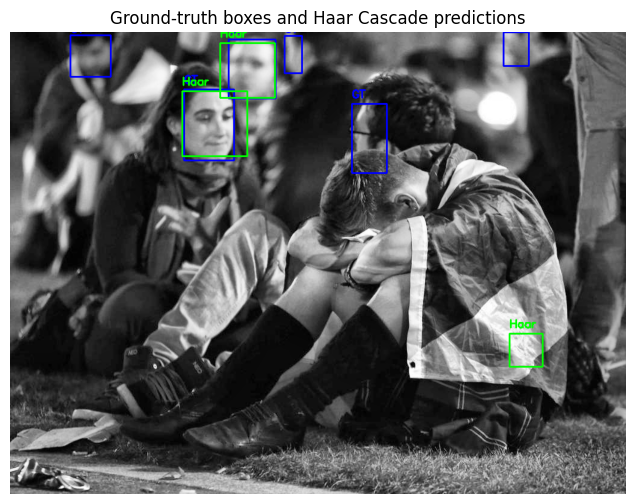

In [ ]:
# Lấy random 1 ảnh từ test
test_image_paths = sorted(list((TEST_DETECTION / "images").glob("*")))

sample_image_path = random.choice(test_image_paths)
sample_label_path = TEST_DETECTION / "labels" / f"{sample_image_path.stem}.txt"

# Đọc ảnh test đã preprocess
gray_image = cv2.imread(str(sample_image_path), cv2.IMREAD_GRAYSCALE)

height, width = gray_image.shape[:2]

# Đọc ground-truth bbox
gt_boxes = read_yolo_label_file(
    label_path=sample_label_path,
    image_width=width,
    image_height=height
)

# Dự đoán bbox bằng Haar Cascade
pred_boxes, elapsed_time = detect_faces_haar(
    gray_image=gray_image,
    scale_factor=best_scale_factor,
    min_neighbors=best_min_neighbors,
    min_size=best_min_size
)

# Đánh giá ảnh này
result = evaluate_single_image(
    pred_boxes=pred_boxes,
    gt_boxes=gt_boxes,
    iou_threshold=0.5
)

# Vẽ GT màu xanh dương/đỏ tùy BGR, pred màu xanh lá
vis_image = draw_boxes(
    image=gray_image,
    boxes=gt_boxes,
    color=(255, 0, 0),
    label="GT"
)

vis_image = draw_boxes(
    image=vis_image,
    boxes=pred_boxes,
    color=(0, 255, 0),
    label="Haar"
)

# In thông tin
print("Image:", sample_image_path.name)
print("GT boxes:", len(gt_boxes))
print("Pred boxes:", len(pred_boxes))
print("TP:", result["tp"])
print("FP:", result["fp"])
print("FN:", result["fn"])
print("Matched IoUs:", result["matched_ious"])
print("Processing time:", round(elapsed_time, 4), "seconds")

# Hiển thị ảnh
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title("Ground-truth boxes and Haar Cascade predictions")
plt.axis("off")
plt.show()

# Save

In [18]:
params_xml_path = DETECTION_MODEL_DIR / "best_haar_params.xml"


# Lưu best params
root = ET.Element("HaarCascadeBestParams")

ET.SubElement(root, "scale_factor").text = str(best_scale_factor)
ET.SubElement(root, "min_neighbors").text = str(best_min_neighbors)

min_size_node = ET.SubElement(root, "min_size")
ET.SubElement(min_size_node, "width").text = str(best_min_size[0])
ET.SubElement(min_size_node, "height").text = str(best_min_size[1])

ET.SubElement(root, "gamma").text = "1.0"
ET.SubElement(root, "clahe_clip_limit").text = "2.0"
ET.SubElement(root, "clahe_tile_grid_size").text = "8,8"
ET.SubElement(root, "iou_threshold").text = "0.5"

tree = ET.ElementTree(root)

tree.write(
    params_xml_path,
    encoding="utf-8",
    xml_declaration=True
)

print("Saved best Haar params to:")
print(params_xml_path)

Saved best Haar params to:
D:\image-processing-project\models\face_detection\best_haar_params.xml
